In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
from matplotlib import pyplot as plt
from src.post_process_functions import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#load data (model)
res_savename_ext = "post_processed_flags_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
#"post_processed_flags_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
#"post_processed_flags_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v230925"
extracted_df = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))

#load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_all_v240925"
labelled_df = pd.read_csv(DATA_OUT_PROC / (res_savename_lab+".csv"))

#split_lowest = False
#suffix = "_geo_split_lowest" if split_lowest else "_geo"
#suffix+="_v250925"
##load geocoded data
#extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix+".gpkg"))
#
##load data (labelled)
#labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix+".gpkg"))
#
##load matched data
#filename_out = f"matched_data_labelled_extracted_row_matching_v120925"
#matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_out + ".feather")#)

In [24]:
#reformat output
from re import match


num_cols = ["impactValue"]#, "geocoding_osm_flag", "geocoding_country_flag"]#"startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"
list_cols_ext = ["country", "location", "hazards", "valueAnnotation", "locationAnnotation", "dateAnnotation", "hazardsAnnotation"]
list_cols_lab = ["country", "location", "hazards", "annotation"]
labelled_df = format_output(labelled_df, num_cols=num_cols, list_cols=list_cols_lab)
extracted_df = format_output(extracted_df, num_cols=num_cols, list_cols=list_cols_ext)
#DEF_CRS_EPSG = "EPSG:4326"
#labelled_df = labelled_df.set_crs(DEF_CRS_EPSG, allow_override=True)
#extracted_df = extracted_df.set_crs(DEF_CRS_EPSG, allow_override=True)
#matched_df = matched_df.set_crs(DEF_CRS_EPSG, allow_override=True)

In [25]:
flag_cols = [label for label in extracted_df.columns if "flag_" in label]

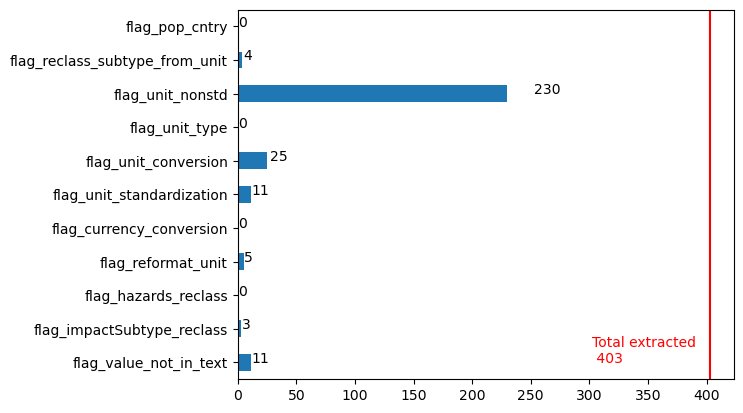

In [26]:
ax = extracted_df[flag_cols].sum().plot(kind="barh")
ax.axvline(len(extracted_df), color="red")
ax.text(len(extracted_df)*0.75, 0, f"Total extracted\n {len(extracted_df)}", color="red")
for i, v in enumerate(extracted_df[flag_cols].sum()):
    ax.text(v*1.1, i, f"{v}", color="black")
#extracted_df[["appealCode"]+ flag_cols].plot(kind="barh")

In [27]:
extracted_df[extracted_df["flag_unit_nonstd"]==True]["impactUnit"].value_counts()

impactUnit
eur                                            12
%                                               6
percent                                         6
km**2                                           4
children                                        2
idp sites                                       1
buildings                                       1
other buildings destroyed (collapsed walls)     1
landslides                                      1
vehicles                                        1
unions                                          1
sub-districts                                   1
districts                                       1
temporary shelters                              1
cases                                           1
provinces                                       1
 cases                                          1
small businesses                                1
vessels                                         1
% of buildings                         

In [28]:
extracted_df[~pd.isna(extracted_df["impactValue"]) & pd.isna(extracted_df["impactUnit"])]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,flag_hazards_reclass,flag_reformat_unit,flag_currency_conversion,flag_unit_standardization,flag_unit_conversion,unit_type,flag_unit_type,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_pop_cntry
351,Human Deaths,3.0,NaN,NaN,exact,NaN,[Three (3) deaths were also reported and800 pe...,[Guinea Bissau],[None],[Three (3) deaths were also reported and800 pe...,...,False,False,False,False,False,other,False,True,False,NaN
390,Residential Buildings,750.0,NaN,NaN,exact,NaN,[It was reported by the National Directorate G...,[Hungary],[Szabolcs-Szatmár-Bereg County],"[On21 June2016, heavy rain and hailstorm hit S...",...,False,False,False,False,False,other,False,True,False,NaN


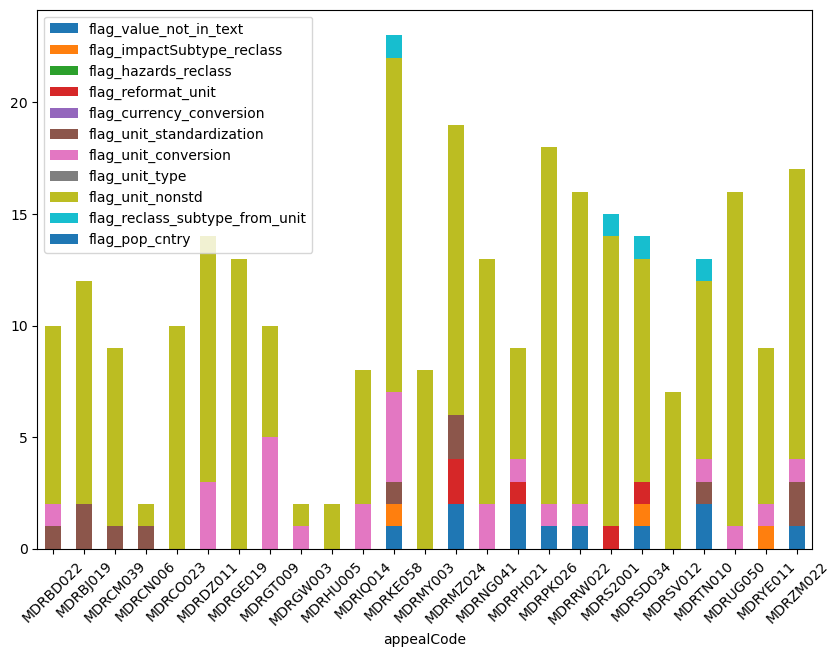

In [ ]:
ax = extracted_df.groupby("appealCode")[flag_cols].sum().plot(kind="bar", figsize=(10,7), rot=45, stacked=True)

In [30]:
extracted_df.groupby("appealCode")[flag_cols].sum()

,flag_value_not_in_text,flag_impactSubtype_reclass,flag_hazards_reclass,flag_reformat_unit,flag_currency_conversion,flag_unit_standardization,flag_unit_conversion,flag_unit_type,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_pop_cntry
appealCode,,,,,,,,,,,
MDRBD022,0,0,0,0,0,1,1,0,8,0,0
MDRBJ019,0,0,0,0,0,2,0,0,10,0,0
MDRCM039,0,0,0,0,0,1,0,0,8,0,0
MDRCN006,0,0,0,0,0,1,0,0,1,0,0
MDRCO023,0,0,0,0,0,0,0,0,10,0,0
MDRDZ011,0,0,0,0,0,0,3,0,11,0,0
MDRGE019,0,0,0,0,0,0,0,0,13,0,0
MDRGT009,0,0,0,0,0,0,5,0,5,0,0
MDRGW003,0,0,0,0,0,0,1,0,1,0,0


In [31]:
extracted_df[extracted_df["appealCode"] == "MDRSD034"][["hazards", "flag_hazards_reclass"]]

,hazards,flag_hazards_reclass
24,"[Flood, Epidemic, Conflict]",False
25,"[Flood, Epidemic]",False
26,[Flood],False
27,"[Flood, Epidemic, Conflict]",False
28,"[Flood, Epidemic, Conflict]",False
29,"[Flood, Epidemic]",False
30,"[Flood, Conflict, Epidemic]",False
31,[Flood],False
32,"[Conflict, Flood, Epidemic]",False
33,[Flood],False
